## Select Cutoff for clustering

- Verify the cutoff value of score _s_ that affects the number of clusters
- The default value of `0.85` was adopted in this study.

&nbsp;

- [SimplifyEnrichment: A Bioconductor Package for Clustering and Visualizing Functional Enrichment Results](https://doi.org/10.1016/j.gpb.2022.04.008)
- [File S12](https://oup.silverchair-cdn.com/oup/backfile/Content_public/Journal/gpb/21/1/10.1016_j.gpb.2022.04.008/3/gpb_21_1_190_mmc12.zip?Expires=1767734081&Signature=cwMGFXGIMhZ5AgzMztq~8pCEKznSgXoARzzgx8TpLVjiCMLavnP0xtJDoEPboASlz9ihdBrXuwf~kdH6QyWsxXHuX653-fs3k03qWAPgt2u5UcVsQFJSJ5CfJaGPcB5jZDgrcJ~6ecHBw188Yuf5x8ygGaUdznN-qyjip0lRLZt8fWXqQGRxFIBGaYNw1U47LdKKAEN~oufeZyqeqWg6Dma3reiGK8DkTQOFwjmjAyO~834X~-iu8HjeEWJwT3CJvweEjI~4gaf~IxUgRfOIf2Lv~soQUoSzqZUATDnff3hgATxt531X6lr~hDK3gUmhh5yXVVw~X4yazaqVhDBsEg__&Key-Pair-Id=APKAIE5G5CRDK6RD3PGA)

In [1]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: aarch64-unknown-linux-gnu
Running under: Debian GNU/Linux 11 (bullseye)

Matrix products: default
BLAS:   /usr/lib/aarch64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/aarch64-linux-gnu/openblas-pthread/libopenblasp-r0.3.13.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C.UTF-8       LC_NUMERIC=C           LC_TIME=C.UTF-8       
 [4] LC_COLLATE=C.UTF-8     LC_MONETARY=C.UTF-8    LC_MESSAGES=C.UTF-8   
 [7] LC_PAPER=C.UTF-8       LC_NAME=C              LC_ADDRESS=C          
[10] LC_TELEPHONE=C         LC_MEASUREMENT=C.UTF-8 LC_IDENTIFICATION=C   

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] digest_0.6.37     IRdisplay_1.1     base64enc_0.1-3   fastmap_1.2.0    
 [5] glue_1.8.0        htmltools_0.5.8.1 repr_1.1.7        lifecycle_1.0.4  
 [9] cli_3.6.5         vctrs_0.6.5       pbdZM

In [2]:
library(simona)
library(simplifyEnrichment)
library(ComplexHeatmap)
library(Cairo)
library(grid)

simona version 1.4.0
Bioconductor page: http://bioconductor.org/packages/simona/
Github page: https://github.com/jokergoo/simona
Documentation: https://jokergoo.github.io/simona/

If you use it in published research, please cite:
Gu, Z. simona: a Comprehensive R package for Semantic Similarity 
  Analysis on Bio-Ontologies. BMC Genomics, 2024.

This message can be suppressed by:
  suppressPackageStartupMessages(library(simona))




simplifyEnrichment version 2.0.0
Bioconductor page: https://bioconductor.org/packages/simplifyEnrichment/
Github page: https://github.com/jokergoo/simplifyEnrichment
Documentation: https://jokergoo.github.io/simplifyEnrichment/
Examples: https://simplifyenrichment.github.io/

If you use it in published research, please cite:
Gu, Z. simplifyEnrichment: an R/Bioconductor package for Clustering and 
  Visualizing Functional Enrichment Results, Genomics, Proteomics & 
  Bioinformatics 2022.

This message can be suppressed by:
  suppressPackageStartupMessages(lib

In [3]:
print(all_term_sim_methods())

 [1] "Sim_Lin_1998"         "Sim_Resnik_1999"      "Sim_FaITH_2010"      
 [4] "Sim_Relevance_2006"   "Sim_SimIC_2010"       "Sim_XGraSM_2013"     
 [7] "Sim_EISI_2015"        "Sim_AIC_2014"         "Sim_Zhang_2006"      
[10] "Sim_universal"        "Sim_Wang_2007"        "Sim_GOGO_2018"       
[13] "Sim_Rada_1989"        "Sim_Resnik_edge_2005" "Sim_Leocock_1998"    
[16] "Sim_WP_1994"          "Sim_Slimani_2006"     "Sim_Shenoy_2012"     
[19] "Sim_Pekar_2002"       "Sim_Stojanovic_2001"  "Sim_Wang_edge_2012"  
[22] "Sim_Zhong_2002"       "Sim_AlMubaid_2006"    "Sim_Li_2003"         
[25] "Sim_RSS_2013"         "Sim_HRSS_2013"        "Sim_Shen_2010"       
[28] "Sim_SSDD_2013"        "Sim_Jiang_1997"       "Sim_Kappa"           
[31] "Sim_Jaccard"          "Sim_Dice"             "Sim_Overlap"         
[34] "Sim_Ancestor"        


&nbsp;

&nbsp;

&nbsp;

# Biological process

### 1) Get Gene Ontology DAGs

In [4]:
# <https://jokergoo.github.io/simona/articles/v02_GO.html>
dag_bp <- create_ontology_DAG_from_GO_db(
  "BP",
  relations = c("part of", "regulates")
) # nolint

# In this analysis, we use the alternative GO release
alternative_GO_terms(
  tag = c("replaced_by", "alt_id", "consider"),
  version = "2025-03-16"
)

relations: is_a, part_of, regulates, negatively_regulates, positively_regulates

Use GO obo version: 2025-03-16


Retrieving mappings between alternative terms to DAG terms.



$`GO:0000003`
 replaced_by 
"GO:0022414" 

$`GO:0000108`
 replaced_by 
"GO:0000109" 

$`GO:0000161`
 replaced_by 
"GO:0038066" 

$`GO:0000170`
 replaced_by 
"GO:0102772" 

$`GO:0000174`
 replaced_by 
"GO:0000750" 

$`GO:0000229`
 replaced_by 
"GO:0005694" 

$`GO:0000260`
 replaced_by 
"GO:0046961" 

$`GO:0000261`
 replaced_by 
"GO:0046962" 

$`GO:0000274`
 replaced_by 
"GO:0045259" 

$`GO:0000275`
 replaced_by 
"GO:0045259" 

$`GO:0000276`
 replaced_by 
"GO:0045259" 

$`GO:0000284`
 replaced_by 
"GO:0000753" 

$`GO:0000291`
 replaced_by 
"GO:0000956" 

$`GO:0000362`
 replaced_by 
"GO:0000384" 

$`GO:0000363`
 replaced_by 
"GO:0000384" 

$`GO:0000364`
 replaced_by 
"GO:0000386" 

$`GO:0000367`
 replaced_by 
"GO:0000386" 

$`GO:0000459`
 replaced_by 
"GO:0006364" 

$`GO:0000469`
 replaced_by 
"GO:0006364" 

$`GO:0000737`
 replaced_by 
"GO:0006308" 

$`GO:0000738`
 replaced_by 
"GO:0006308" 

$`GO:0000904`
 replaced_by 
"GO:0000902" 

$`GO:0001054`
 replaced_by 
"GO:0003899" 

$`GO:0001055`
 replaced_by 
"GO:0003899" 

$`GO:0001056`
 replaced_by 
"GO:0003899" 

$`GO:0001057`
 replaced_by 
"GO:0003899" 

$`GO:0001058`
 replaced_by 
"GO:0003899" 

$`GO:0001061`
 replaced_by 
"GO:0003899" 

$`GO:0001062`
 replaced_by 
"GO:0003899" 

$`GO:0001063`
 replaced_by 
"GO:0003899" 

$`GO:0001064`
 replaced_by 
"GO:0003899" 

$`GO:0001065`
 replaced_by 
"GO:0003899" 

$`GO:0001066`
 replaced_by 
"GO:0003899" 

$`GO:0001134`
 replaced_by 
"GO:0003712" 

$`GO:0001135`
 replaced_by 
"GO:0003712" 

$`GO:0001186`
 replaced_by 
"GO:0003712" 

$`GO:0001509`
 replaced_by 
"GO:0004197" 

$`GO:0001524`
 replaced_by 
"GO:0005344" 

$`GO:0001528`
 replaced_by 
"GO:0030023" 

$`GO:0001529`
 replaced_by 
"GO:0030023" 

$`GO:0001564`
 replaced_by 
"GO:0001562" 

$`GO:0001683`
 replaced_by 
"GO:0005858" 

$`GO:0001684`
 replaced_by 
"GO:0005858" 

$`GO:0001685`
 replaced_by 
"GO:0005858" 

$`GO:0001686`
 replaced_by 
"GO:0005858" 

$`GO:0001687`
 replaced_by 
"GO:0005868" 

$`GO:0001688`
 replaced_by 
"GO:0005868" 

$`GO:0001689`
 replaced_by 
"GO:0005868" 

$`GO:0001690`
 replaced_by 
"GO:0005868" 

$`GO:0001721`
 replaced_by 
"GO:0005882" 

$`GO:0001722`
 replaced_by 
"GO:0005882" 

$`GO:0001723`
 replaced_by 
"GO:0005882" 

$`GO:0001724`
 replaced_by 
"GO:0045098" 

$`GO:0002032`
 replaced_by 
"GO:0002029" 

$`GO:0002083`
 replaced_by 
"GO:0008412" 

$`GO:0002094`
 replaced_by 
"GO:0004659" 

$`GO:0002169`
 replaced_by 
"GO:1905202" 

$`GO:0003721`
 replaced_by 
"GO:0003720" 

$`GO:0003733`
 replaced_by 
"GO:1990904" 

$`GO:0003734`
 replaced_by 
"GO:0030532" 

$`GO:0003750`
 replaced_by 
"GO:0051726" 

$`GO:0003763`
 replaced_by     consider 
"GO:0016887" "GO:0006457" 

$`GO:0003776`
 replaced_by     consider     consider 
"GO:0000146" "GO:0006936" "GO:0043292" 

$`GO:0003781`
 replaced_by 
"GO:0051017" 

$`GO:0003782`
 replaced_by 
"GO:0051016" 

$`GO:0003783`
 replaced_by 
"GO:0051016" 

$`GO:0003787`
 replaced_by 
"GO:0030042" 

$`GO:0003792`
 replaced_by 
"GO:0030832" 

$`GO:0003802`
 replaced_by 
"GO:0004252" 

$`GO:0003803`
 replaced_by 
"GO:0004252" 

$`GO:0003804`
 replaced_by 
"GO:0004252" 

$`GO:0003805`
 replaced_by 
"GO:0004252" 

$`GO:0003806`
 replaced_by 
"GO:0004252" 

$`GO:0003807`
 replaced_by 
"GO:0004252" 

$`GO:0003808`
 replaced_by 
"GO:0004252" 

$`GO:0003809`
 replaced_by 
"GO:0004252" 

$`GO:0003812`
 replaced_by 
"GO:0004252" 

$`GO:0003813`
 replaced_by 
"GO:0004252" 

$`GO:0003815`
 replaced_by 
"GO:0004252" 

$`GO:0003816`
 replaced_by 
"GO:0004252" 

$`GO:0003817`
 replaced_by 
"GO:0004252" 

$`GO:0003818`
 replaced_by 
"GO:0004252" 

$`GO:0003859`
 replaced_by 
"GO:0018812" 

$`GO:0003896`
 replaced_by 
"GO:0003899" 

$`GO:0003900`
 replaced_by 
"GO:0003899" 

$`GO:0003901`
 replaced_by 
"GO:0003899" 

$`GO:0003902`
 replaced_by 
"GO:0003899" 

$`GO:0003926`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:0016192" 

$`GO:0003928`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:00

In [5]:
rice_goa_enrichment_result_bp <- read.table(
  "../Data/10_enrichment_result_viz/BP_enrichment_up_modified.tsv", # nolint
  header = TRUE,
  sep = "\t"
)

rice_top_go_ids_bp <- rice_goa_enrichment_result_bp$GO
show(rice_top_go_ids_bp)

 [1] "GO:0006457" "GO:0009266" "GO:0009408" "GO:0042542" "GO:0051259"
 [6] "GO:0000302" "GO:0006950" "GO:0009628" "GO:0042026" "GO:0034620"
[11] "GO:0042221" "GO:1901700" "GO:0006986" "GO:0035967" "GO:0035966"
[16] "GO:0006970" "GO:0009651" "GO:0050896" "GO:0051085" "GO:0051084"
[21] "GO:0061077" "GO:0006458" "GO:0009631" "GO:0006979" "GO:0097305"
[26] "GO:0033554" "GO:0051716" "GO:0034605" "GO:0045471" "GO:0034976"
[31] "GO:0065003" "GO:0043933" "GO:0046688" "GO:0010466" "GO:0052547"
[36] "GO:0045861" "GO:0051346" "GO:0009414" "GO:0009737" "GO:0046685"
[41] "GO:0051248" "GO:0009415" "GO:0022607" "GO:0001101" "GO:0036503"
[46] "GO:0051336" "GO:0009409"


In [6]:
mat_bp <- term_sim(dag_bp, rice_top_go_ids_bp, method = "Sim_WP_1994")
print(mat_bp)

term_sim_method: Sim_WP_1994

collecting all ancestors of input terms ...


going through 0 / 87 ancestors ...

going through 87 / 87 ancestors ... Done.

collecting all ancestors of input terms ...


going through 0 / 87 ancestors ...

going through 87 / 87 ancestors ... Done.



           GO:0006457 GO:0009266 GO:0009408 GO:0042542 GO:0051259 GO:0000302
GO:0006457  1.0000000  0.0000000  0.0000000  0.0000000  0.1538462  0.0000000
GO:0009266  0.0000000  1.0000000  0.8571429  0.2500000  0.0000000  0.2857143
GO:0009408  0.0000000  0.8571429  1.0000000  0.5000000  0.0000000  0.5714286
GO:0042542  0.0000000  0.2500000  0.5000000  1.0000000  0.0000000  0.8888889
GO:0051259  0.1538462  0.0000000  0.0000000  0.0000000  1.0000000  0.0000000
GO:0000302  0.0000000  0.2857143  0.5714286  0.8888889  0.0000000  1.0000000
GO:0006950  0.0000000  0.4000000  0.8000000  0.5714286  0.0000000  0.6666667
GO:0009628  0.0000000  0.8000000  0.6666667  0.2857143  0.0000000  0.3333333
GO:0042026  0.9333333  0.0000000  0.0000000  0.0000000  0.1428571  0.0000000
GO:0034620  0.1666667  0.2500000  0.5000000  0.4000000  0.1818182  0.4444444
GO:0042221  0.0000000  0.4000000  0.3333333  0.5714286  0.0000000  0.6666667
GO:1901700  0.0000000  0.3333333  0.2857143  0.7500000  0.0000000  0.8571429

Perform keywords enrichment for 4 GO lists...



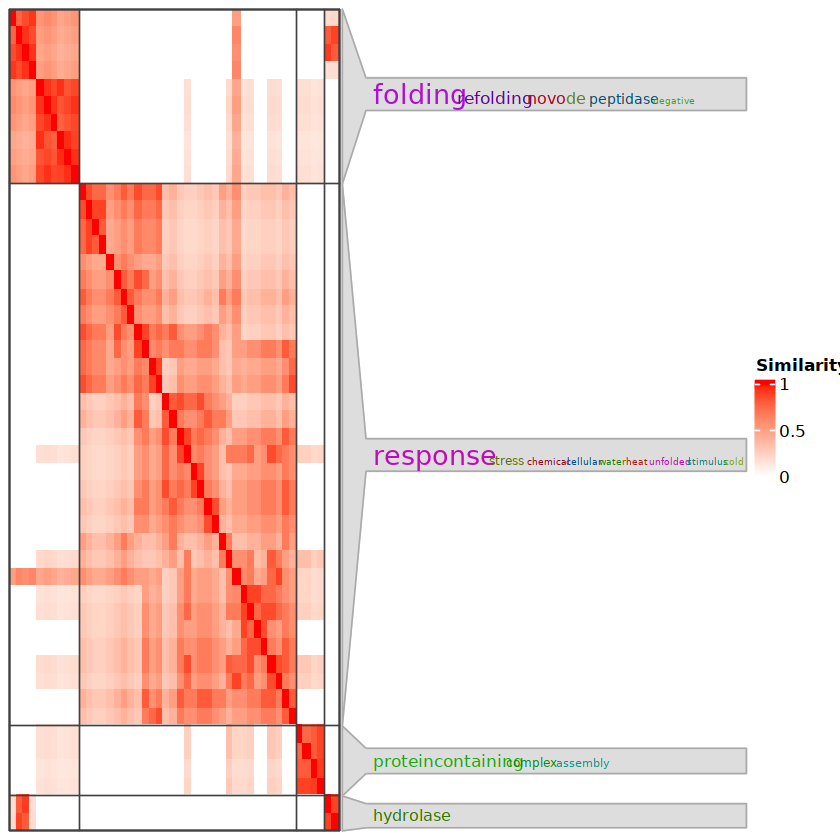

In [7]:
cl_bp <- binary_cut(mat_bp)

ht_clusters(
  mat_bp,
  cl_bp
)

1/41, cutoff = 0.5...

2/41, cutoff = 0.51...

3/41, cutoff = 0.52...

4/41, cutoff = 0.53...

5/41, cutoff = 0.54...

6/41, cutoff = 0.55...

7/41, cutoff = 0.56...

8/41, cutoff = 0.57...

9/41, cutoff = 0.58...

10/41, cutoff = 0.59...

11/41, cutoff = 0.6...

12/41, cutoff = 0.61...

13/41, cutoff = 0.62...

14/41, cutoff = 0.63...

15/41, cutoff = 0.64...

16/41, cutoff = 0.65...

17/41, cutoff = 0.66...

18/41, cutoff = 0.67...

19/41, cutoff = 0.68...

20/41, cutoff = 0.69...

21/41, cutoff = 0.7...

22/41, cutoff = 0.71...

23/41, cutoff = 0.72...

24/41, cutoff = 0.73...

25/41, cutoff = 0.74...

26/41, cutoff = 0.75...

27/41, cutoff = 0.76...

28/41, cutoff = 0.77...

29/41, cutoff = 0.78...

30/41, cutoff = 0.79...

31/41, cutoff = 0.8...

32/41, cutoff = 0.81...

33/41, cutoff = 0.82...

34/41, cutoff = 0.83...

35/41, cutoff = 0.84...

36/41, cutoff = 0.85...

37/41, cutoff = 0.86...

38/41, cutoff = 0.87...

39/41, cutoff = 0.88...

40/41, cutoff = 0.89...

41/41, cutoff

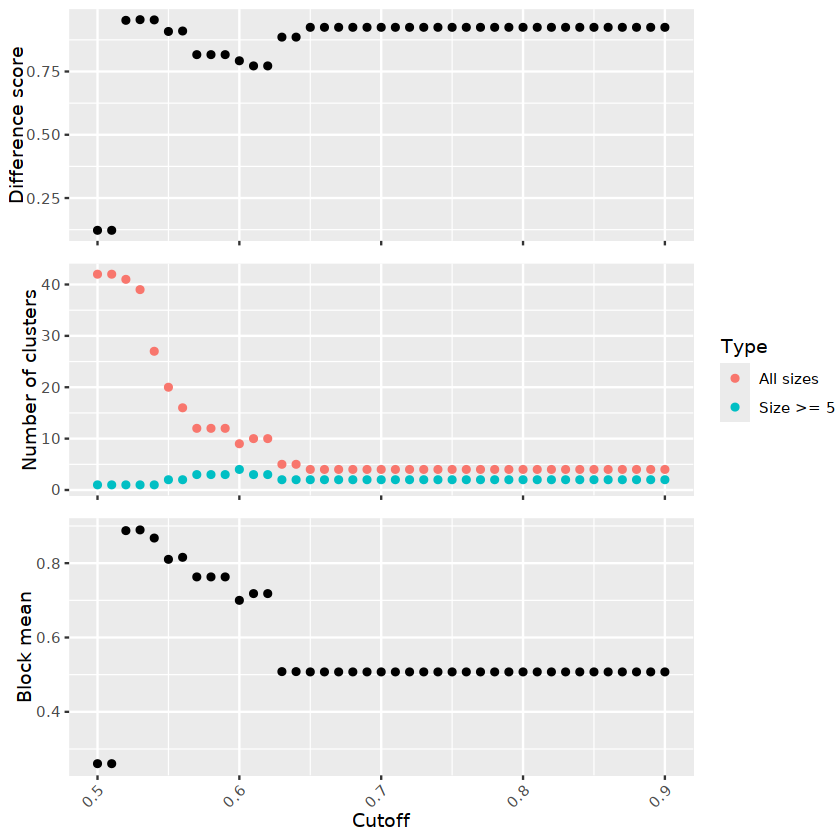

In [8]:
select_cutoff(
  mat_bp,
  cutoff = seq(0.5, 0.9, by = 0.01),
  verbose = TRUE
)

&nbsp;

&nbsp;

&nbsp;

# Cellular Component

### 1) Get Gene Ontology DAGs

In [9]:
# <https://jokergoo.github.io/simona/articles/v02_GO.html>
dag_cc <- create_ontology_DAG_from_GO_db(
  "CC",
  relations = c("part of", "regulates")
) # nolint

# In this analysis, we use the alternative GO release
alternative_GO_terms(
  tag = c("replaced_by", "alt_id", "consider"),
  version = "2025-03-16"
)

relations: is_a, part_of, regulates, negatively_regulates, positively_regulates

Use GO obo version: 2025-03-16


Retrieving mappings between alternative terms to DAG terms.



$`GO:0000003`
 replaced_by 
"GO:0022414" 

$`GO:0000108`
 replaced_by 
"GO:0000109" 

$`GO:0000161`
 replaced_by 
"GO:0038066" 

$`GO:0000170`
 replaced_by 
"GO:0102772" 

$`GO:0000174`
 replaced_by 
"GO:0000750" 

$`GO:0000229`
 replaced_by 
"GO:0005694" 

$`GO:0000260`
 replaced_by 
"GO:0046961" 

$`GO:0000261`
 replaced_by 
"GO:0046962" 

$`GO:0000274`
 replaced_by 
"GO:0045259" 

$`GO:0000275`
 replaced_by 
"GO:0045259" 

$`GO:0000276`
 replaced_by 
"GO:0045259" 

$`GO:0000284`
 replaced_by 
"GO:0000753" 

$`GO:0000291`
 replaced_by 
"GO:0000956" 

$`GO:0000362`
 replaced_by 
"GO:0000384" 

$`GO:0000363`
 replaced_by 
"GO:0000384" 

$`GO:0000364`
 replaced_by 
"GO:0000386" 

$`GO:0000367`
 replaced_by 
"GO:0000386" 

$`GO:0000459`
 replaced_by 
"GO:0006364" 

$`GO:0000469`
 replaced_by 
"GO:0006364" 

$`GO:0000737`
 replaced_by 
"GO:0006308" 

$`GO:0000738`
 replaced_by 
"GO:0006308" 

$`GO:0000904`
 replaced_by 
"GO:0000902" 

$`GO:0001054`
 replaced_by 
"GO:0003899" 

$`GO:0001055`
 replaced_by 
"GO:0003899" 

$`GO:0001056`
 replaced_by 
"GO:0003899" 

$`GO:0001057`
 replaced_by 
"GO:0003899" 

$`GO:0001058`
 replaced_by 
"GO:0003899" 

$`GO:0001061`
 replaced_by 
"GO:0003899" 

$`GO:0001062`
 replaced_by 
"GO:0003899" 

$`GO:0001063`
 replaced_by 
"GO:0003899" 

$`GO:0001064`
 replaced_by 
"GO:0003899" 

$`GO:0001065`
 replaced_by 
"GO:0003899" 

$`GO:0001066`
 replaced_by 
"GO:0003899" 

$`GO:0001134`
 replaced_by 
"GO:0003712" 

$`GO:0001135`
 replaced_by 
"GO:0003712" 

$`GO:0001186`
 replaced_by 
"GO:0003712" 

$`GO:0001509`
 replaced_by 
"GO:0004197" 

$`GO:0001524`
 replaced_by 
"GO:0005344" 

$`GO:0001528`
 replaced_by 
"GO:0030023" 

$`GO:0001529`
 replaced_by 
"GO:0030023" 

$`GO:0001564`
 replaced_by 
"GO:0001562" 

$`GO:0001683`
 replaced_by 
"GO:0005858" 

$`GO:0001684`
 replaced_by 
"GO:0005858" 

$`GO:0001685`
 replaced_by 
"GO:0005858" 

$`GO:0001686`
 replaced_by 
"GO:0005858" 

$`GO:0001687`
 replaced_by 
"GO:0005868" 

$`GO:0001688`
 replaced_by 
"GO:0005868" 

$`GO:0001689`
 replaced_by 
"GO:0005868" 

$`GO:0001690`
 replaced_by 
"GO:0005868" 

$`GO:0001721`
 replaced_by 
"GO:0005882" 

$`GO:0001722`
 replaced_by 
"GO:0005882" 

$`GO:0001723`
 replaced_by 
"GO:0005882" 

$`GO:0001724`
 replaced_by 
"GO:0045098" 

$`GO:0002032`
 replaced_by 
"GO:0002029" 

$`GO:0002083`
 replaced_by 
"GO:0008412" 

$`GO:0002094`
 replaced_by 
"GO:0004659" 

$`GO:0002169`
 replaced_by 
"GO:1905202" 

$`GO:0003721`
 replaced_by 
"GO:0003720" 

$`GO:0003733`
 replaced_by 
"GO:1990904" 

$`GO:0003734`
 replaced_by 
"GO:0030532" 

$`GO:0003750`
 replaced_by 
"GO:0051726" 

$`GO:0003763`
 replaced_by     consider 
"GO:0016887" "GO:0006457" 

$`GO:0003776`
 replaced_by     consider     consider 
"GO:0000146" "GO:0006936" "GO:0043292" 

$`GO:0003781`
 replaced_by 
"GO:0051017" 

$`GO:0003782`
 replaced_by 
"GO:0051016" 

$`GO:0003783`
 replaced_by 
"GO:0051016" 

$`GO:0003787`
 replaced_by 
"GO:0030042" 

$`GO:0003792`
 replaced_by 
"GO:0030832" 

$`GO:0003802`
 replaced_by 
"GO:0004252" 

$`GO:0003803`
 replaced_by 
"GO:0004252" 

$`GO:0003804`
 replaced_by 
"GO:0004252" 

$`GO:0003805`
 replaced_by 
"GO:0004252" 

$`GO:0003806`
 replaced_by 
"GO:0004252" 

$`GO:0003807`
 replaced_by 
"GO:0004252" 

$`GO:0003808`
 replaced_by 
"GO:0004252" 

$`GO:0003809`
 replaced_by 
"GO:0004252" 

$`GO:0003812`
 replaced_by 
"GO:0004252" 

$`GO:0003813`
 replaced_by 
"GO:0004252" 

$`GO:0003815`
 replaced_by 
"GO:0004252" 

$`GO:0003816`
 replaced_by 
"GO:0004252" 

$`GO:0003817`
 replaced_by 
"GO:0004252" 

$`GO:0003818`
 replaced_by 
"GO:0004252" 

$`GO:0003859`
 replaced_by 
"GO:0018812" 

$`GO:0003896`
 replaced_by 
"GO:0003899" 

$`GO:0003900`
 replaced_by 
"GO:0003899" 

$`GO:0003901`
 replaced_by 
"GO:0003899" 

$`GO:0003902`
 replaced_by 
"GO:0003899" 

$`GO:0003926`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:0016192" 

$`GO:0003928`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:00

In [10]:
rice_goa_enrichment_result_cc <- read.table(
  "../Data/10_enrichment_result_viz/CC_enrichment_up_modified.tsv", # nolint
  header = TRUE,
  sep = "\t"
)
rice_top_go_ids_cc <- rice_goa_enrichment_result_cc$GO
show(rice_top_go_ids_cc)

[1] "GO:0005788" "GO:0005783" "GO:0005737" "GO:0034663"


In [11]:
mat_cc <- term_sim(dag_cc, rice_top_go_ids_cc, method = "Sim_WP_1994")
print(mat_cc)

term_sim_method: Sim_WP_1994

collecting all ancestors of input terms ...


going through 0 / 17 ancestors ...

going through 17 / 17 ancestors ... Done.

collecting all ancestors of input terms ...


going through 0 / 17 ancestors ...

going through 17 / 17 ancestors ... Done.



           GO:0005788 GO:0005783 GO:0005737 GO:0034663
GO:0005788  1.0000000  0.9090909  0.7500000  0.7692308
GO:0005783  0.9090909  1.0000000  0.8571429  0.8333333
GO:0005737  0.7500000  0.8571429  1.0000000  0.6666667
GO:0034663  0.7692308  0.8333333  0.6666667  1.0000000


Perform keywords enrichment for 1 GO lists...



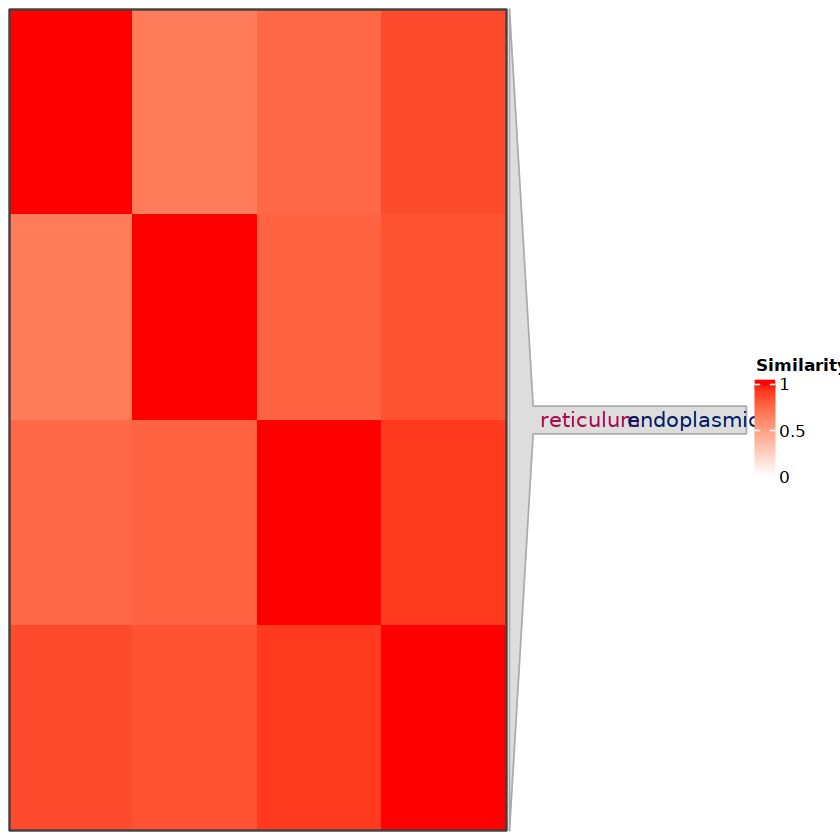

In [12]:
cl_cc <- binary_cut(mat_cc)

ht_clusters(
  mat_cc,
  cl_cc
)

1/50, cutoff = 0.5...

2/50, cutoff = 0.51...

3/50, cutoff = 0.52...

4/50, cutoff = 0.53...

5/50, cutoff = 0.54...

6/50, cutoff = 0.55...

7/50, cutoff = 0.56...

8/50, cutoff = 0.57...

9/50, cutoff = 0.58...

10/50, cutoff = 0.59...

11/50, cutoff = 0.6...

12/50, cutoff = 0.61...

13/50, cutoff = 0.62...

14/50, cutoff = 0.63...

15/50, cutoff = 0.64...

16/50, cutoff = 0.65...

17/50, cutoff = 0.66...

18/50, cutoff = 0.67...

19/50, cutoff = 0.68...

20/50, cutoff = 0.69...

21/50, cutoff = 0.7...

22/50, cutoff = 0.71...

23/50, cutoff = 0.72...

24/50, cutoff = 0.73...

25/50, cutoff = 0.74...

26/50, cutoff = 0.75...

27/50, cutoff = 0.76...

28/50, cutoff = 0.77...

29/50, cutoff = 0.78...

30/50, cutoff = 0.79...

31/50, cutoff = 0.8...

32/50, cutoff = 0.81...

33/50, cutoff = 0.82...

34/50, cutoff = 0.83...

35/50, cutoff = 0.84...

36/50, cutoff = 0.85...

37/50, cutoff = 0.86...

38/50, cutoff = 0.87...

39/50, cutoff = 0.88...

40/50, cutoff = 0.89...

41/50, cutoff

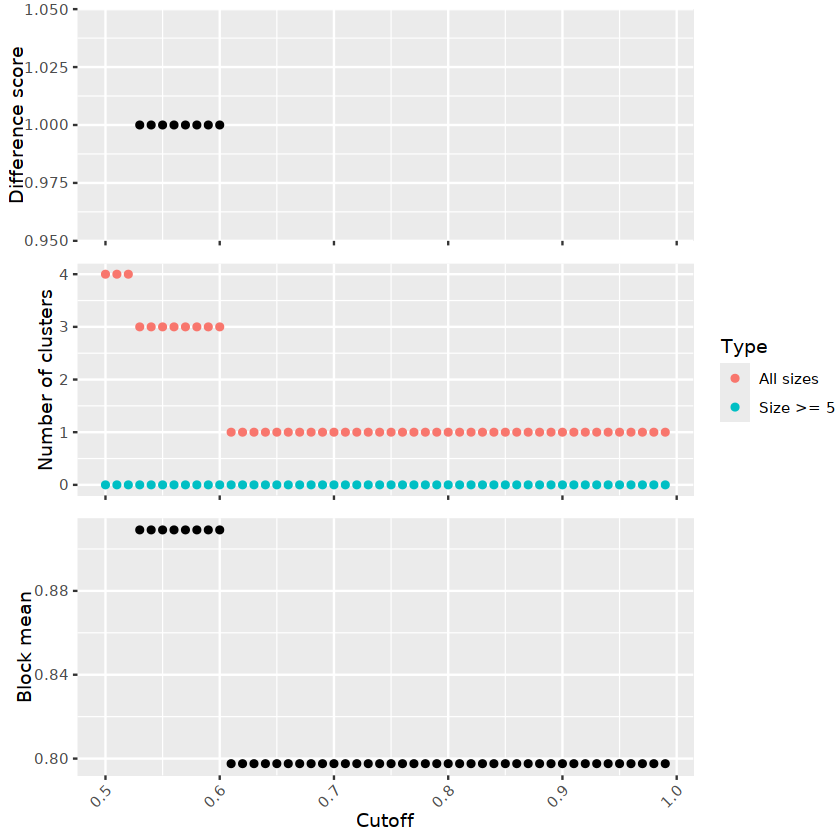

In [13]:
select_cutoff(
  mat_cc,
  cutoff = seq(0.5, 0.99, by = 0.01),
  verbose = TRUE
)

&nbsp;

&nbsp;

&nbsp;

# Molecular Function

### 1) Get Gene Ontology DAGs

In [14]:
# <https://jokergoo.github.io/simona/articles/v02_GO.html>
dag_mf <- create_ontology_DAG_from_GO_db(
  "MF",
  relations = c("part of", "regulates")
) # nolint

# In this analysis, we use the alternative GO release
alternative_GO_terms(
  tag = c("replaced_by", "alt_id", "consider"),
  version = "2025-03-16"
)

relations: is_a, part_of, regulates, negatively_regulates, positively_regulates

Use GO obo version: 2025-03-16


Retrieving mappings between alternative terms to DAG terms.



$`GO:0000003`
 replaced_by 
"GO:0022414" 

$`GO:0000108`
 replaced_by 
"GO:0000109" 

$`GO:0000161`
 replaced_by 
"GO:0038066" 

$`GO:0000170`
 replaced_by 
"GO:0102772" 

$`GO:0000174`
 replaced_by 
"GO:0000750" 

$`GO:0000229`
 replaced_by 
"GO:0005694" 

$`GO:0000260`
 replaced_by 
"GO:0046961" 

$`GO:0000261`
 replaced_by 
"GO:0046962" 

$`GO:0000274`
 replaced_by 
"GO:0045259" 

$`GO:0000275`
 replaced_by 
"GO:0045259" 

$`GO:0000276`
 replaced_by 
"GO:0045259" 

$`GO:0000284`
 replaced_by 
"GO:0000753" 

$`GO:0000291`
 replaced_by 
"GO:0000956" 

$`GO:0000362`
 replaced_by 
"GO:0000384" 

$`GO:0000363`
 replaced_by 
"GO:0000384" 

$`GO:0000364`
 replaced_by 
"GO:0000386" 

$`GO:0000367`
 replaced_by 
"GO:0000386" 

$`GO:0000459`
 replaced_by 
"GO:0006364" 

$`GO:0000469`
 replaced_by 
"GO:0006364" 

$`GO:0000737`
 replaced_by 
"GO:0006308" 

$`GO:0000738`
 replaced_by 
"GO:0006308" 

$`GO:0000904`
 replaced_by 
"GO:0000902" 

$`GO:0001054`
 replaced_by 
"GO:0003899" 

$`GO:0001055`
 replaced_by 
"GO:0003899" 

$`GO:0001056`
 replaced_by 
"GO:0003899" 

$`GO:0001057`
 replaced_by 
"GO:0003899" 

$`GO:0001058`
 replaced_by 
"GO:0003899" 

$`GO:0001061`
 replaced_by 
"GO:0003899" 

$`GO:0001062`
 replaced_by 
"GO:0003899" 

$`GO:0001063`
 replaced_by 
"GO:0003899" 

$`GO:0001064`
 replaced_by 
"GO:0003899" 

$`GO:0001065`
 replaced_by 
"GO:0003899" 

$`GO:0001066`
 replaced_by 
"GO:0003899" 

$`GO:0001134`
 replaced_by 
"GO:0003712" 

$`GO:0001135`
 replaced_by 
"GO:0003712" 

$`GO:0001186`
 replaced_by 
"GO:0003712" 

$`GO:0001509`
 replaced_by 
"GO:0004197" 

$`GO:0001524`
 replaced_by 
"GO:0005344" 

$`GO:0001528`
 replaced_by 
"GO:0030023" 

$`GO:0001529`
 replaced_by 
"GO:0030023" 

$`GO:0001564`
 replaced_by 
"GO:0001562" 

$`GO:0001683`
 replaced_by 
"GO:0005858" 

$`GO:0001684`
 replaced_by 
"GO:0005858" 

$`GO:0001685`
 replaced_by 
"GO:0005858" 

$`GO:0001686`
 replaced_by 
"GO:0005858" 

$`GO:0001687`
 replaced_by 
"GO:0005868" 

$`GO:0001688`
 replaced_by 
"GO:0005868" 

$`GO:0001689`
 replaced_by 
"GO:0005868" 

$`GO:0001690`
 replaced_by 
"GO:0005868" 

$`GO:0001721`
 replaced_by 
"GO:0005882" 

$`GO:0001722`
 replaced_by 
"GO:0005882" 

$`GO:0001723`
 replaced_by 
"GO:0005882" 

$`GO:0001724`
 replaced_by 
"GO:0045098" 

$`GO:0002032`
 replaced_by 
"GO:0002029" 

$`GO:0002083`
 replaced_by 
"GO:0008412" 

$`GO:0002094`
 replaced_by 
"GO:0004659" 

$`GO:0002169`
 replaced_by 
"GO:1905202" 

$`GO:0003721`
 replaced_by 
"GO:0003720" 

$`GO:0003733`
 replaced_by 
"GO:1990904" 

$`GO:0003734`
 replaced_by 
"GO:0030532" 

$`GO:0003750`
 replaced_by 
"GO:0051726" 

$`GO:0003763`
 replaced_by     consider 
"GO:0016887" "GO:0006457" 

$`GO:0003776`
 replaced_by     consider     consider 
"GO:0000146" "GO:0006936" "GO:0043292" 

$`GO:0003781`
 replaced_by 
"GO:0051017" 

$`GO:0003782`
 replaced_by 
"GO:0051016" 

$`GO:0003783`
 replaced_by 
"GO:0051016" 

$`GO:0003787`
 replaced_by 
"GO:0030042" 

$`GO:0003792`
 replaced_by 
"GO:0030832" 

$`GO:0003802`
 replaced_by 
"GO:0004252" 

$`GO:0003803`
 replaced_by 
"GO:0004252" 

$`GO:0003804`
 replaced_by 
"GO:0004252" 

$`GO:0003805`
 replaced_by 
"GO:0004252" 

$`GO:0003806`
 replaced_by 
"GO:0004252" 

$`GO:0003807`
 replaced_by 
"GO:0004252" 

$`GO:0003808`
 replaced_by 
"GO:0004252" 

$`GO:0003809`
 replaced_by 
"GO:0004252" 

$`GO:0003812`
 replaced_by 
"GO:0004252" 

$`GO:0003813`
 replaced_by 
"GO:0004252" 

$`GO:0003815`
 replaced_by 
"GO:0004252" 

$`GO:0003816`
 replaced_by 
"GO:0004252" 

$`GO:0003817`
 replaced_by 
"GO:0004252" 

$`GO:0003818`
 replaced_by 
"GO:0004252" 

$`GO:0003859`
 replaced_by 
"GO:0018812" 

$`GO:0003896`
 replaced_by 
"GO:0003899" 

$`GO:0003900`
 replaced_by 
"GO:0003899" 

$`GO:0003901`
 replaced_by 
"GO:0003899" 

$`GO:0003902`
 replaced_by 
"GO:0003899" 

$`GO:0003926`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:0016192" 

$`GO:0003928`
 replaced_by     consider     consider 
"GO:0003924" "GO:0016191" "GO:00

In [15]:
rice_goa_enrichment_result_mf <- read.table(
  "../Data/10_enrichment_result_viz/MF_enrichment_up_modified.tsv", # nolint
  header = TRUE,
  sep = "\t"
)

rice_top_go_ids_mf <- rice_goa_enrichment_result_mf$GO
show(rice_top_go_ids_mf)

 [1] "GO:0051082" "GO:0140662" "GO:0044183" "GO:0031072" "GO:0051787"
 [6] "GO:0060590" "GO:0140657" "GO:0051087" "GO:0051879" "GO:0016887"
[11] "GO:0140487" "GO:0000774" "GO:0004867" "GO:0005515" "GO:0140313"
[16] "GO:0017111" "GO:0140315" "GO:0030414" "GO:0004866" "GO:0061135"
[21] "GO:0061134" "GO:0098772" "GO:0016462" "GO:0016818" "GO:0016817"


In [16]:
mat_mf <- term_sim(dag_mf, rice_top_go_ids_mf, method = "Sim_WP_1994")
print(mat_mf)

term_sim_method: Sim_WP_1994

collecting all ancestors of input terms ...


going through 0 / 32 ancestors ...

going through 32 / 32 ancestors ... Done.

collecting all ancestors of input terms ...


going through 0 / 32 ancestors ...

going through 32 / 32 ancestors ... Done.



           GO:0051082 GO:0140662 GO:0044183 GO:0031072 GO:0051787 GO:0060590
GO:0051082  1.0000000  0.0000000  0.0000000  0.6666667  0.6666667  0.0000000
GO:0140662  0.0000000  1.0000000  0.6666667  0.0000000  0.0000000  0.0000000
GO:0044183  0.0000000  0.6666667  1.0000000  0.0000000  0.0000000  0.0000000
GO:0031072  0.6666667  0.0000000  0.0000000  1.0000000  0.6666667  0.0000000
GO:0051787  0.6666667  0.0000000  0.0000000  0.6666667  1.0000000  0.0000000
GO:0060590  0.0000000  0.0000000  0.0000000  0.0000000  0.0000000  1.0000000
GO:0140657  0.0000000  0.6666667  0.0000000  0.0000000  0.0000000  0.0000000
GO:0051087  0.6666667  0.0000000  0.0000000  0.6666667  0.6666667  0.0000000
GO:0051879  0.5714286  0.0000000  0.0000000  0.8571429  0.5714286  0.0000000
GO:0016887  0.0000000  0.5000000  0.0000000  0.0000000  0.0000000  0.0000000
GO:0140487  0.0000000  0.0000000  0.0000000  0.0000000  0.0000000  0.0000000
GO:0000774  0.0000000  0.0000000  0.0000000  0.0000000  0.0000000  0.8000000

Perform keywords enrichment for 5 GO lists...



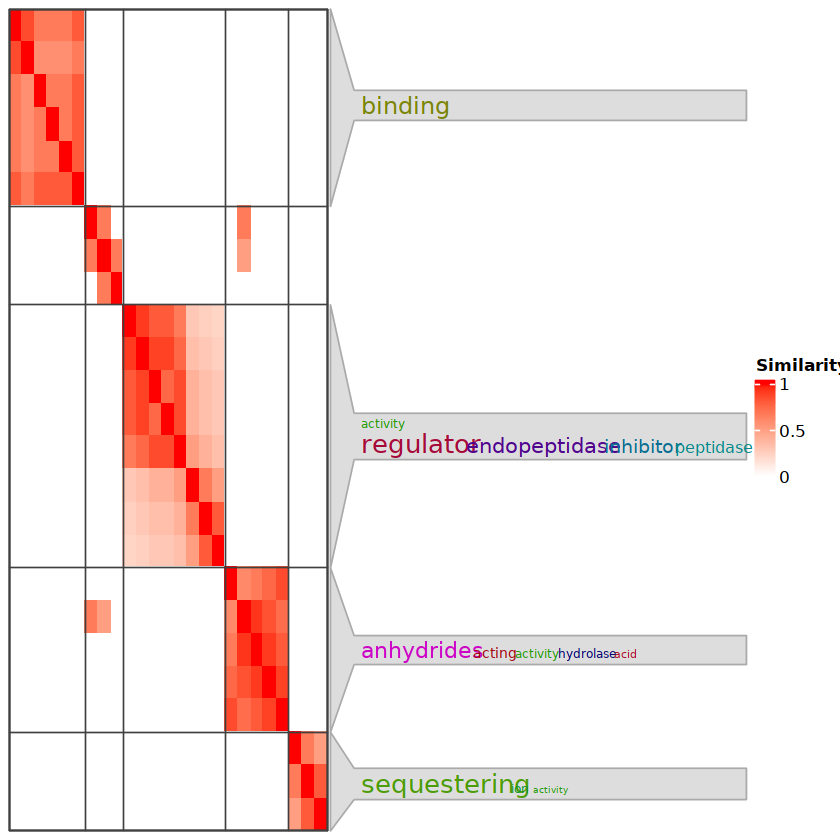

In [17]:
cl_mf <- binary_cut(mat_mf)

ht_clusters(
  mat_mf,
  cl_mf
)

1/50, cutoff = 0.5...

2/50, cutoff = 0.51...

3/50, cutoff = 0.52...

4/50, cutoff = 0.53...

5/50, cutoff = 0.54...

6/50, cutoff = 0.55...

7/50, cutoff = 0.56...

8/50, cutoff = 0.57...

9/50, cutoff = 0.58...

10/50, cutoff = 0.59...

11/50, cutoff = 0.6...

12/50, cutoff = 0.61...

13/50, cutoff = 0.62...

14/50, cutoff = 0.63...

15/50, cutoff = 0.64...

16/50, cutoff = 0.65...

17/50, cutoff = 0.66...

18/50, cutoff = 0.67...

19/50, cutoff = 0.68...

20/50, cutoff = 0.69...

21/50, cutoff = 0.7...

22/50, cutoff = 0.71...

23/50, cutoff = 0.72...

24/50, cutoff = 0.73...

25/50, cutoff = 0.74...

26/50, cutoff = 0.75...

27/50, cutoff = 0.76...

28/50, cutoff = 0.77...

29/50, cutoff = 0.78...

30/50, cutoff = 0.79...

31/50, cutoff = 0.8...

32/50, cutoff = 0.81...

33/50, cutoff = 0.82...

34/50, cutoff = 0.83...

35/50, cutoff = 0.84...

36/50, cutoff = 0.85...

37/50, cutoff = 0.86...

38/50, cutoff = 0.87...

39/50, cutoff = 0.88...

40/50, cutoff = 0.89...

41/50, cutoff

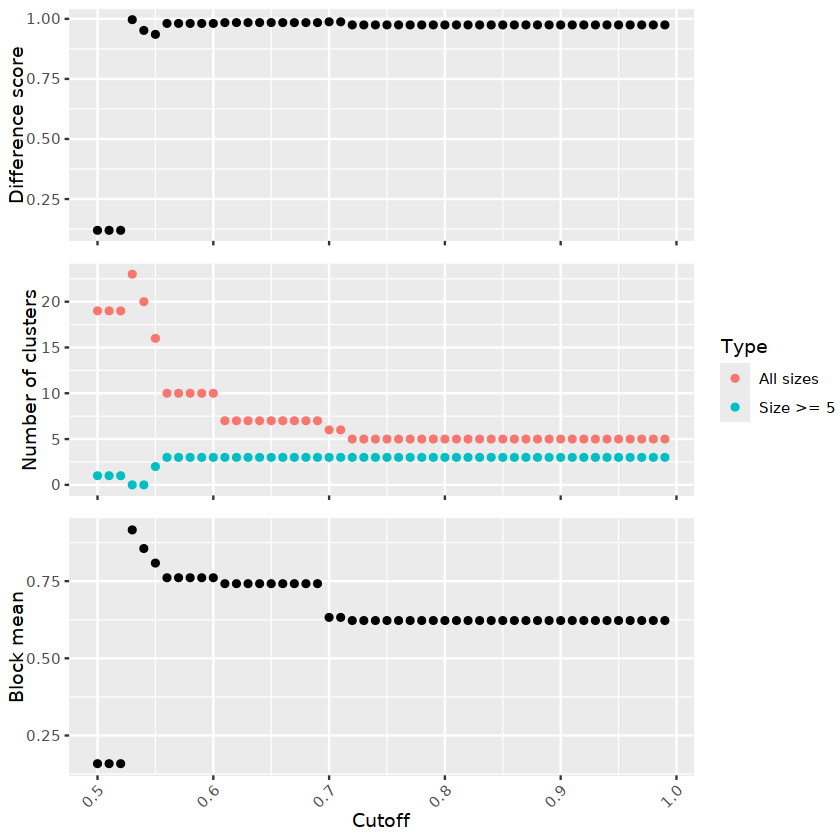

In [18]:
select_cutoff(
  mat_mf,
  cutoff = seq(0.5, 0.99, by = 0.01),
  verbose = TRUE
)